# FastOTF2 Converter — Scaling & Performance Notebook

A single notebook that **collects** converter timings across traces and node counts, then
**graphs** strong- and weak-scaling behaviour. It replaces `converter-scaling.ipynb` and
`perf_matrix.ipynb`.

**Workflow**
1. *Setup* (§0): download the container, configure the `e4s-cl` environment, create a
   timestamped run folder.
2. *Inventory* (§1): measure each trace's real size — this drives the weak-scaling math.
3. *Design* (§2): one cell decides **what** to run — `STRONG`, `WEAK`, or `ALL`. Set
   `DRY_RUN = True` first to sanity-check submission and graphs with a tiny, fast matrix.
4. *Submit* (§3): dependency-chained Slurm jobs; timings captured via `--timings-csv`.
5. *Analyse* (§5+): load the CSVs and draw graphs with **plotnine**. This half is
   self-contained — to study a **previous** run (no new data), restart the kernel, run the
   §5 config cell with `ANALYZE_RUN` set, then run the graph cells.

**Conventions**
- **`traced_nodes`** = the node count a trace was *captured* on (its size label);
  **`nl`** = the converter launch node count (`-nl`).
- Sizes are **GiB (1024³)**, measured with `du -sb` (fixes the old `du -h` / `humanfriendly`
  decimal mismatch).
- **Strong** scaling fixes a trace and varies `nl`. **Weak** scaling gives each trace a
  *bespoke* `nl = round(size / target)` so data-per-node stays ≈ constant.

# 0. Environment, container & e4s-cl setup

Prepares everything a job needs: Python imports, user paths, a **timestamped run folder**
(so runs never clobber each other), the OFI container (pulled/converted to a `.sif`), and
the `e4s-cl` profile (binds host paths + sources the OTF2 pre-exec script). Each run of this
section creates a fresh run folder; to **analyse a previous run** without collecting new
data, skip straight to §5 and set `ANALYZE_RUN` there.

In [ ]:
# --- Imports ---
import os
import re
import json
import subprocess
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from plotnine import *  # noqa: F401,F403

import workflows

# --- User parameters (edit for your environment) ---
go_dir              = "/lus/scratch/crickett/go/"
apptainer_bin_path  = "/lus/scratch/crickett/software/usr/bin"
apptainer_cache_dir = "/lus/bnchlu1/khandeka/.local/apptainer/"

container_url   = "ghcr.io/hpc-ai-adv-dev/fastotf2/fastotf2-converter-libfabric2.3.1:latest"
entrypoint_path = "/workspace/fastotf2/apps/FastOTF2Converter/target/release/FastOTF2Converter_real"

STRATEGY     = "locgroup_dist_block"   # multi-locale distribution strategy
FORMAT       = "PARQUET"               # converter output format
THREAD_COUNT = 64                       # --cpus-per-task per job

# --- Run folder & logging ---
WORKFLOW_DIR = Path.cwd()               # the workflows/scaling directory

# Every execution of this cell starts a NEW, timestamped run folder — it never clobbers a
# previous run. (To *analyse* an existing run without collecting new data, don't touch this;
# jump to §5 and set ANALYZE_RUN there.)
RUN_TAG = f"run_{datetime.now():%Y%m%d_%H%M%S}"

RUN_DIR            = WORKFLOW_DIR / "out" / RUN_TAG
TIMINGS_DIR        = RUN_DIR / "timings"         # full-sweep --timings-csv output (tiny)
SAMPLE_TIMINGS_DIR = RUN_DIR / "timings_sample"  # SAMPLE_RUN timings live here instead, so a
                                                  # quick sample can never mix with a full sweep
SLURM_LOG_DIR = RUN_DIR / "slurm_logs"   # sbatch job stdout/stderr
RUN_LOG_DIR   = RUN_DIR / "run_logs"     # per-run scripts + converter.log
OUTPUT_ROOT   = RUN_DIR / "pq"           # converter Parquet output (large; safe to delete)
PLOTS_DIR     = RUN_DIR / "plots"        # saved figures (optional)

for d in (RUN_DIR, TIMINGS_DIR, SAMPLE_TIMINGS_DIR, SLURM_LOG_DIR, RUN_LOG_DIR,
          OUTPUT_ROOT, PLOTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

workflows.set_workflow_log(str(RUN_DIR / "workflow.log"))  # note: this chdir's to RUN_DIR ...
os.chdir(WORKFLOW_DIR)                                      # ... so restore the workflow dir

print(f"RUN_TAG : {RUN_TAG}")
print(f"RUN_DIR : {RUN_DIR}")
print(f"timings : {TIMINGS_DIR}  (sample timings: {SAMPLE_TIMINGS_DIR})")

In [ ]:
# Environment variables for apptainer / e4s-cl
os.environ["APPTAINER_CACHEDIR"] = apptainer_cache_dir
os.environ["PATH"] = (os.environ.get("PATH", "") + os.pathsep + os.path.join(go_dir, "bin")
                      + os.pathsep + apptainer_bin_path)
os.environ["LD_LIBRARY_PATH"] = (os.environ.get("LD_LIBRARY_PATH", "") + os.pathsep
                                 + os.path.join(go_dir, "lib"))

# Download (or reuse) the container as a .sif in the workflow directory
workflows.print_and_log(f"Fetching container: {container_url}")
container_name = workflows.download_custom_container(container_url)
container_path = str(WORKFLOW_DIR / container_name)
print(f"Container: {container_path}")

# Pre-exec script sourced inside the container (OTF2 libs + Chapel comm heap).
# CHPL_RT_MAX_HEAP_SIZE caps the fixed communication heap the NIC must pin per node;
# 70% was too large to register on the Slingshot/CXI NIC (multi-locale jobs died at
# init), so we use 50%.
preexec_path = WORKFLOW_DIR / "e4s-cl-preexec.sh"
preexec_path.write_text(
    "#!/bin/bash\n"
    'export LD_LIBRARY_PATH="/opt/otf2/lib:${LD_LIBRARY_PATH}"\n'
    "export CHPL_RT_MAX_HEAP_SIZE=50%\n"
)

# Register host paths with the e4s-cl profile so the container can read/write them.
# WORKFLOW_DIR contains RUN_DIR, so the run's outputs/timings are covered here;
# trace directories (elsewhere on the filesystem) are added in §1.
workflows.run_cmd(f"e4s-cl profile edit --add-files {WORKFLOW_DIR}")
workflows.run_cmd(f"e4s-cl profile edit --source {preexec_path}")
print("e4s-cl profile updated (workflow dir + pre-exec).")

# 1. Trace inventory & sizes

Measures each trace's real on-disk size with `du -sb` (bytes → GiB) and caches it to
`trace_sizes.json` (sizes are fixed, so this runs once). These sizes drive the
weak-scaling math in §2. Each trace directory is also registered with the `e4s-cl` profile
so the container can read it.

In [ ]:
# Traces keyed by the node count they were CAPTURED on (the "size" label).
TRACE_INPUTS = {
    2:   "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-2-node-single-HPL-run",
    4:   "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-4-node-single-HPL-run",
    8:   "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-8-node-single-HPL-run",
    16:  "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-16-node-single-HPL-run",
    32:  "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-32-node-single-HPL-run",
    128: "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-128-node-single-HPL-run",
    384: "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-384-node-single-HPL-run",
}
TRACE_FILE = "traces.otf2"            # file within each trace directory
_GIB = 1024 ** 3


def measure_trace_sizes_gib(trace_inputs, cache_path):
    """du -sb each trace dir -> GiB, cached to JSON (trace sizes are fixed)."""
    cache_path = Path(cache_path)
    cache = json.loads(cache_path.read_text()) if cache_path.exists() else {}
    sizes = {}
    for traced_nodes, path in trace_inputs.items():
        key = str(traced_nodes)
        if key not in cache:
            out = subprocess.run(["du", "-sb", path], capture_output=True, text=True, check=True)
            cache[key] = int(out.stdout.split()[0]) / _GIB
        sizes[traced_nodes] = cache[key]
    cache_path.write_text(json.dumps(cache, indent=2, sort_keys=True))
    return sizes


trace_sizes_gib = measure_trace_sizes_gib(TRACE_INPUTS, RUN_DIR / "trace_sizes.json")

# Register trace dirs with the e4s-cl profile (so the container can read them).
for path in TRACE_INPUTS.values():
    workflows.run_cmd(f"e4s-cl profile edit --add-files {path}")

trace_table = pd.DataFrame(
    [(t, round(trace_sizes_gib[t], 3), TRACE_INPUTS[t]) for t in sorted(TRACE_INPUTS)],
    columns=["traced_nodes", "size_GiB", "path"],
)
display(trace_table)

# 2. Experiment design — what to run

Two independent switches at the top of the cell:

- **`SAMPLE_RUN`** — a small but *real* matrix (4 small traces, node grid `1–16`, 2 weak
  targets, 1 trial) that still draws proper strong-scaling **lines** (≥ 4 points/trace) and
  weak-scaling **curves** (≥ 3 traces/target). Use it to check the pipeline and that the
  graphs look right before committing to the overnight run. Its timings go to
  `timings_sample/` so they never mix with a full sweep. Set `SAMPLE_RUN = False` for the
  full matrix.
- **`DRY_RUN`** — a *true* dry run: §3 submits **nothing**, it just prints the jobs that
  *would* be launched. Works with either the sample or the full matrix.

The `plan.json` written here records the chosen weak targets so §5 draws exactly the curves
advertised below (no separate hard-coded target list).

`COLLECTION_MODE`: **STRONG** (each trace on the `NODE_COUNTS` grid within its bounds),
**WEAK** (each trace on a bespoke `nl = round(size / target)` so data/node ≈ constant — it
does *not* reuse the strong grid), or **ALL** (the union; collect once, draw everything).

**Why the weak targets take thought.** Trace sizes span ~0.7 GiB → 1.5 TiB, so no single
GiB/node target fits every trace (small traces would need `< 1` node; the 1.5 TiB trace
needs `≥ 64`). We therefore use several targets, each covering the subset of traces whose
integer node count is feasible — printed below. `NODE_BOUNDS` encodes memory *minimums* for
the largest traces and a *stepped ceiling*, clipped to `MAX_NODES = 256`.

In [ ]:
# ============================ EXPERIMENT DESIGN ============================
SAMPLE_RUN = True    # True: small but real matrix to check the pipeline + graphs.
                     # False: the full sweep.
DRY_RUN    = False   # True: submit NOTHING in §3 — just print the jobs that WOULD run.
                     # (works with either the sample or the full matrix)

COLLECTION_MODE = "ALL"                        # "STRONG" | "WEAK" | "ALL"
TRACES_TO_INCLUDE = [2, 4, 8, 16, 32, 128, 384]

# Strong-scaling node grid (weak scaling computes its own node counts).
NODE_COUNTS = [1, 2, 4, 8, 16, 32, 64, 128, 256]

# Global node cap: the system has ~800 nodes, but we cap at 256 to keep runs affordable.
MAX_NODES = 256

# Per-trace (min_nodes, max_nodes):
#   min -> the two largest traces need enough nodes to fit in memory (cf. is_valid_combo)
#   max -> stepped "diminishing returns" ceiling that grows with trace size
NODE_BOUNDS = {
    2:   (1, 8),
    4:   (1, 16),
    8:   (1, 32),
    16:  (1, 32),
    32:  (1, 64),
    128: (16, 128),
    384: (64, 256),
}

# Weak-scaling targets (GiB/node): an explicit list, or "auto" to derive from the data.
WEAK_TARGETS_GIB_PER_NODE = "auto"
WEAK_TOLERANCE       = 0.1   # a trace joins curve g only if |actual - g| / g <= this
MIN_TRACES_PER_CURVE = 3     # a target must cover >= this many traces to be worth plotting

# Repetition & Slurm knobs
NUM_TRIALS       = 3
WARMUP           = False           # one unrecorded run per config before the timed trials
WALLTIME         = "00:30:00"      # fixed; even the slowest jobs finish < 15 min
EXCLUSIVE        = True            # #SBATCH --exclusive -> clean, non-shared perf numbers
KILL_ON_BAD_EXIT = True            # srun --kill-on-bad-exit=1

# ---- Sample-run overrides: a small but real matrix, sized so the graphs are actually
# useful -- each trace gets >= 4 strong-scaling node counts (real lines), and each weak
# target covers all 4 traces (real curves). Only the smallest/fastest traces are used.
# Everything else (mode, bounds, --exclusive, ...) is left as the full sweep would use it. ----
if SAMPLE_RUN:
    TRACES_TO_INCLUDE = [2, 4, 8, 16]          # small/fast traces
    NODE_COUNTS = [1, 2, 4, 8, 16]              # >= 4 strong points per trace -> real lines
    WEAK_TARGETS_GIB_PER_NODE = "auto"
    NUM_TRIALS = 1                              # one trial is enough for a look
    WALLTIME = "00:15:00"                       # small traces finish in well under this


def _bounds(traced_nodes):
    lo, hi = NODE_BOUNDS[traced_nodes]
    return lo, min(hi, MAX_NODES)


def weak_nodes(traced_nodes, g):
    """Bespoke node count for weak target g. Returns (nodes, actual_g, ok, reason)."""
    size = trace_sizes_gib[traced_nodes]
    lo, hi = _bounds(traced_nodes)
    n = max(1, int(round(size / g)))
    if n < lo:
        return n, size / n, False, f"n={n} < min {lo}"
    if n > hi:
        return n, size / n, False, f"n={n} > max {hi}"
    actual = size / n
    if abs(actual - g) / g > WEAK_TOLERANCE:
        return n, actual, False, f"actual {actual:.2f} >{WEAK_TOLERANCE:.0%} from {g}"
    return n, actual, True, "ok"


def auto_weak_targets():
    """Log-space scan of GiB/node; keep well-covered, geometrically-spaced targets."""
    lows = [trace_sizes_gib[t] / _bounds(t)[1] for t in TRACES_TO_INCLUDE]
    highs = [trace_sizes_gib[t] / _bounds(t)[0] for t in TRACES_TO_INCLUDE]
    picked = []
    for g in np.geomspace(min(lows), max(highs), 30):
        g = round(float(g), 2)
        cov = sum(weak_nodes(t, g)[2] for t in TRACES_TO_INCLUDE)
        if cov >= MIN_TRACES_PER_CURVE and (not picked or g / picked[-1] >= 1.7):
            picked.append(g)
    return picked


weak_targets = (auto_weak_targets() if WEAK_TARGETS_GIB_PER_NODE == "auto"
                else list(WEAK_TARGETS_GIB_PER_NODE))


def weak_coverage_table(targets):
    rows = []
    for g in targets:
        for t in TRACES_TO_INCLUDE:
            n, actual, ok, reason = weak_nodes(t, g)
            rows.append({"target_GiB_per_node": g, "traced_nodes": t,
                         "size_GiB": round(trace_sizes_gib[t], 2), "nodes": n,
                         "actual_GiB_per_node": round(actual, 2),
                         "included": ok, "reason": reason})
    return pd.DataFrame(rows)


# ---- Build the (trace, nodes) configs for the chosen mode ----
strong_cfgs = set()
if COLLECTION_MODE in ("STRONG", "ALL"):
    for t in TRACES_TO_INCLUDE:
        lo, hi = _bounds(t)
        strong_cfgs |= {(t, n) for n in NODE_COUNTS if lo <= n <= hi}

weak_cfgs, weak_curves = set(), {}
if COLLECTION_MODE in ("WEAK", "ALL"):
    for g in weak_targets:
        members = []
        for t in TRACES_TO_INCLUDE:
            n, actual, ok, _ = weak_nodes(t, g)
            if ok:
                members.append((t, n))
        if len(members) >= MIN_TRACES_PER_CURVE:
            weak_curves[g] = members
            weak_cfgs |= set(members)

configs = sorted(strong_cfgs | weak_cfgs)

# ---- Expand into one row per (config, trial) ----
runs_df = pd.DataFrame([
    {"traced_nodes": t, "nl": n, "trial": trial,
     "trace_path": os.path.join(TRACE_INPUTS[t], TRACE_FILE),
     "size_GiB": round(trace_sizes_gib[t], 3),
     "gib_per_node": round(trace_sizes_gib[t] / n, 3),
     "in_strong": (t, n) in strong_cfgs, "in_weak": (t, n) in weak_cfgs}
    for (t, n) in configs for trial in range(1, NUM_TRIALS + 1)
]).sort_values(["traced_nodes", "nl", "trial"]).reset_index(drop=True)

# ---- Persist the plan so §5 draws exactly these weak targets/curves (even for a previous
# run analysed in a fresh kernel), and so submission/analysis never drift apart. Crucially
# this also records WHICH (trace, nl) pairs are true strong-scaling grid points vs weak's
# bespoke ones -- under COLLECTION_MODE="ALL" both land in the same timings/ folder with no
# other way to tell them apart, so without this Graph 1 would mix weak's non-power-of-two
# node counts into the strong-scaling plots. ----
plan = {
    "collection_mode": COLLECTION_MODE,
    "traces": TRACES_TO_INCLUDE,
    "node_counts": NODE_COUNTS,
    "weak_targets": weak_targets,
    "weak_tolerance": WEAK_TOLERANCE,
    "min_traces_per_curve": MIN_TRACES_PER_CURVE,
    "weak_curves": {str(g): members for g, members in weak_curves.items()},
    "strong_configs": sorted(list(c) for c in strong_cfgs),
    "weak_configs": sorted(list(c) for c in weak_cfgs),
    "num_trials": NUM_TRIALS,
    "sample_run": SAMPLE_RUN,
    "dry_run": DRY_RUN,
}
(RUN_DIR / "plan.json").write_text(json.dumps(plan, indent=2))

# ---- Report the plan (so you see the cost before submitting) ----
n_jobs = len(runs_df) + (len(configs) if WARMUP else 0)
print("*** SAMPLE RUN (small, real) ***" if SAMPLE_RUN else "*** FULL SWEEP ***",
      "   [DRY RUN — nothing will be submitted]" if DRY_RUN else "")
print(f"MODE = {COLLECTION_MODE}   traces = {TRACES_TO_INCLUDE}")
print(f"unique (trace, nodes) configs = {len(configs)}   trials = {NUM_TRIALS}"
      f"   total jobs = {n_jobs}{' (incl. warmup)' if WARMUP else ''}")
print(f"weak targets (GiB/node) = {weak_targets}")
if weak_curves:
    print("weak curves that will be plotted:")
    for g, members in sorted(weak_curves.items()):
        pts = ", ".join(f"s{t}->{n}n(~{trace_sizes_gib[t] / n:.2f})" for t, n in sorted(members))
        print(f"  {g:>5} GiB/node : {pts}")
print("\nWeak-scaling coverage (audit — why each trace is in/out per target):")
display(weak_coverage_table(weak_targets))
print("First planned runs:")
display(runs_df.head(12))

# 3. Build & submit the sweep

Each config becomes one Slurm job: `e4s-cl launch … srun … <converter> -nl<N> <trace>
--timings-csv <dir>`. Jobs are **dependency-chained** (`--dependency afterany:<prev>`) so
they run one at a time — clean, non-overlapping timings with no polling loop.

- **`DRY_RUN = True`** → this cell **submits nothing**; it just prints each job that would be
  launched. Nothing is written, no `sbatch` is called.
- **`SAMPLE_RUN`** → jobs/folders are tagged `sample-…`, Parquet output goes under `pq/`, and
  timings go to `timings_sample/` (kept separate from a full sweep's `timings/`).

Per-run artifacts (the `sbatch` script, `run_args.json`, `converter.log`) are written under
`run_logs/`, and a `manifest*.csv` records every job id.

In [ ]:
def build_job_script(nl, trace_path, converter_log, output_dir, timings_subdir):
    """Text of the per-run sbatch script: e4s-cl launch + srun + converter."""
    srun_args = [f"--nodes={nl}", "--ntasks-per-node=1", f"--cpus-per-task={THREAD_COUNT}",
                 f"--time={WALLTIME}", f"--output={converter_log}"]
    if EXCLUSIVE:
        srun_args.append("--exclusive")
    if KILL_ON_BAD_EXIT:
        srun_args.append("--kill-on-bad-exit=1")
    converter_args = [f"-nl{nl}", trace_path, f"--strategy={STRATEGY}", f"--format={FORMAT}",
                      f"--outputDir={output_dir}", "--log=WARN", f"--timings-csv {timings_subdir}"]
    cmd = ["e4s-cl", "launch", f"--image={container_path}", "srun", *srun_args,
           "--", entrypoint_path, *converter_args]
    return "#!/bin/bash\n" + " ".join(cmd) + "\n"


def submit_one(traced_nodes, nl, trial, prev_job_id, warmup=False):
    # `tag` stays regex-parseable (size{N}_nl{M}_trial{T}) for the analysis loader;
    # `label` adds a sample- prefix purely for human-readable folder/job names.
    tag = f"size{traced_nodes}_nl{nl}_" + ("warmup" if warmup else f"trial{trial}")
    label = ("sample-" if SAMPLE_RUN else "") + tag
    trace_path = os.path.join(TRACE_INPUTS[traced_nodes], TRACE_FILE)
    job_name = f"f2-{'sample-' if SAMPLE_RUN else ''}s{traced_nodes}-nl{nl}-t{trial}"

    # True dry run: report the job and do nothing else (no dirs, no files, no sbatch).
    if DRY_RUN:
        print(f"  [dry] would submit {job_name}: -nl{nl}, "
              f"trace s{traced_nodes} ({trace_sizes_gib[traced_nodes]:.2f} GiB), "
              f"--time {WALLTIME}")
        return "DRYRUN"

    # Sample timings go to a separate root so a quick sample never mixes with a full sweep;
    # warmup timings always go to a throwaway dir so they never enter the analysis set.
    timings_root = SAMPLE_TIMINGS_DIR if SAMPLE_RUN else TIMINGS_DIR
    timings_subdir = (RUN_DIR / "warmup_timings" / label) if warmup else (timings_root / tag)
    output_dir = OUTPUT_ROOT / label
    per_run = RUN_LOG_DIR / label
    per_run.mkdir(parents=True, exist_ok=True)
    output_dir.mkdir(parents=True, exist_ok=True)

    script_path = per_run / "sbatch_script.sh"
    script_path.write_text(build_job_script(nl, trace_path, str(per_run / "converter.log"),
                                             str(output_dir), str(timings_subdir)))
    (per_run / "run_args.json").write_text(json.dumps(
        {"traced_nodes": traced_nodes, "nl": nl, "trial": trial, "warmup": warmup,
         "sample_run": SAMPLE_RUN, "trace_path": trace_path,
         "strategy": STRATEGY, "format": FORMAT}, indent=2))

    sbatch_cmd = ["sbatch", "--parsable", f"--job-name={job_name}",
                  f"--nodes={nl}", "--ntasks-per-node=1", f"--cpus-per-task={THREAD_COUNT}",
                  f"--time={WALLTIME}", f"--output={SLURM_LOG_DIR / (label + '-%j.out')}"]
    if EXCLUSIVE:
        sbatch_cmd.append("--exclusive")
    if prev_job_id is not None:
        sbatch_cmd += ["--dependency", f"afterany:{prev_job_id}"]
    sbatch_cmd.append(str(script_path))
    (per_run / "submission_command.txt").write_text(" ".join(sbatch_cmd) + "\n")

    res = subprocess.run(sbatch_cmd, capture_output=True, text=True)
    if res.returncode != 0:
        workflows.print_and_log(f"[{label}] sbatch FAILED: {res.stderr.strip()}")
        return None
    return res.stdout.strip().split(";")[0]


# ---- Submit everything, dependency-chained (or preview, if DRY_RUN) ----
if DRY_RUN:
    print(f"*** DRY RUN — nothing will be submitted *** {len(runs_df)} jobs would launch:")
else:
    print(f"*** {'SAMPLE RUN' if SAMPLE_RUN else 'FULL SWEEP'} *** submitting "
          f"{len(runs_df) + (len(configs) if WARMUP else 0)} jobs (dependency-chained)")

prev_job_id = None
manifest_rows = []

if WARMUP and not DRY_RUN:
    for (t, n) in configs:
        prev_job_id = submit_one(t, n, 0, prev_job_id, warmup=True) or prev_job_id

for _, r in runs_df.iterrows():
    jid = submit_one(int(r.traced_nodes), int(r.nl), int(r.trial), prev_job_id)
    if jid and jid != "DRYRUN":
        prev_job_id = jid
    manifest_rows.append({**r.to_dict(), "sample_run": SAMPLE_RUN, "job_id": jid})

manifest = pd.DataFrame(manifest_rows)
manifest_name = ("manifest_dryrun.csv" if DRY_RUN
                 else "manifest_sample.csv" if SAMPLE_RUN else "manifest.csv")
manifest.to_csv(RUN_DIR / manifest_name, index=False)
if DRY_RUN:
    print(f"\nDry run complete — no jobs submitted. Preview manifest: {RUN_DIR / manifest_name}")
else:
    n_ok = (manifest["job_id"].notna() & (manifest["job_id"] != "DRYRUN")).sum()
    print(f"Submitted {n_ok} / {len(manifest)} jobs (dependency-chained). "
          f"Manifest: {RUN_DIR / manifest_name}")
display(manifest.head(12))

# 4. Monitor the queue (optional)

Jobs run serially via the dependency chain, so timing CSVs appear one-by-one under
`timings/`. Use the widget below to watch the queue, or run
`workflows.wait_until_my_jobs_finished()` to block until the sweep is done. Nothing here is
required for the analysis — it just reads whatever CSVs already exist.

In [ ]:
# Live squeue monitor (press Start). Safe to skip.
workflows.watch_queue_widget()

# Or, to block until everything finishes, run:
# workflows.wait_until_my_jobs_finished()

# 5. Results analysis

**Self-contained** — this half only needs a run's timings folder, so you can restart the
kernel and run just §5 onward.

- To analyse the run you just submitted, leave **`ANALYZE_RUN = None`** (the default).
- To analyse a **previous** run *without collecting new data*, set **`ANALYZE_RUN`** to that
  run's tag (e.g. `"run_20260714_101500"`) or a full path to its folder.
- **`ANALYZE_SAMPLE`** picks the sample timings (`timings_sample/`) vs the full sweep's
  (`timings/`); it defaults to whatever `SAMPLE_RUN` was this session.

Weak-scaling targets are read from the run's `plan.json`, so the graphs draw **exactly** the
curves §2 advertised (no separate hard-coded list). Trace sizes come from the run's cached
`trace_sizes.json`; timings come straight from the converter's CSVs (`run_*.csv`,
`tasks_*.csv`, `phases_*.csv`) — no log parsing.

In [ ]:
# --- Analysis configuration (self-contained: this half runs on its own) ---
import re, json
from pathlib import Path
import numpy as np
import pandas as pd
from plotnine import *  # noqa: F401,F403

# === Which run to analyse? =================================================
# None  -> the run created above in this kernel session (needs §0-§3 to have run).
# tag   -> a previous run's tag, e.g. "run_20260714_101500"
# path  -> a full path to a run folder OR directly to its timings/ folder
# Use this to analyse an existing run WITHOUT collecting new data: restart the
# kernel, set ANALYZE_RUN here, then run this cell and the graph cells below.
ANALYZE_RUN = None

# Read the small SAMPLE run's timings (timings_sample/) or the full sweep's (timings/)?
# Defaults to whatever SAMPLE_RUN was in this session, else the full-sweep timings.
ANALYZE_SAMPLE = globals().get("SAMPLE_RUN", False)

# Where run folders live — used to turn a bare ANALYZE_RUN tag into a path.
OUT_ROOT = (WORKFLOW_DIR / "out") if "WORKFLOW_DIR" in globals() else Path(
    "/lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/workflows/scaling/out")


def resolve_timings_dir(analyze_run, sample):
    """Resolve the timings folder to analyse from a tag, a path, or the live session."""
    sub = "timings_sample" if sample else "timings"
    if analyze_run is None:                                  # this session's run
        if "TIMINGS_DIR" in globals():
            return SAMPLE_TIMINGS_DIR if sample else TIMINGS_DIR
        raise RuntimeError("No run in this kernel — set ANALYZE_RUN to a past run tag/path.")
    p = Path(analyze_run)
    if p.exists():                                            # a full path was given
        return p if p.name.startswith("timings") else (p / sub)
    return OUT_ROOT / str(analyze_run) / sub                 # a bare run tag


HOST_TIMINGS_DIR = resolve_timings_dir(ANALYZE_RUN, ANALYZE_SAMPLE)
RUN_DIR_ANALYSIS = Path(HOST_TIMINGS_DIR).parent
if not Path(HOST_TIMINGS_DIR).exists():
    raise FileNotFoundError(f"Timings folder not found: {HOST_TIMINGS_DIR}\n"
                            "Check ANALYZE_RUN / ANALYZE_SAMPLE.")

# Trace sizes (GiB) for GiB/node derivations — from the run's cached JSON.
_sizes_json = RUN_DIR_ANALYSIS / "trace_sizes.json"
if _sizes_json.exists():
    trace_sizes_gib = {int(k): v for k, v in json.loads(_sizes_json.read_text()).items()}
elif "trace_sizes_gib" not in globals():
    raise RuntimeError(f"No trace_sizes.json at {_sizes_json}; set trace_sizes_gib manually.")

# Weak-scaling targets for the graphs: reuse the plan that PRODUCED this run (plan.json), so
# §5 draws exactly the curves §2 advertised. Fall back to in-session values, then a default
# sweep, only when analysing an older run that has no plan.json.
_plan = {}
_plan_json = RUN_DIR_ANALYSIS / "plan.json"
if _plan_json.exists():
    _plan = json.loads(_plan_json.read_text())
WEAK_TARGETS_ANALYSIS = _plan.get("weak_targets") or globals().get("weak_targets") or [0.5, 1.0, 3.0, 6.0, 12.0]
WEAK_TOL_ANALYSIS     = _plan.get("weak_tolerance", globals().get("WEAK_TOLERANCE", 0.4))
MIN_TRACES_ANALYSIS   = _plan.get("min_traces_per_curve", globals().get("MIN_TRACES_PER_CURVE", 3))

# Which (trace, nl) pairs are true strong-scaling grid points vs weak-scaling's bespoke
# ones. Both get collected into the same timings folder under COLLECTION_MODE="ALL" with
# no other tag distinguishing them, so Graph 1 uses this to avoid plotting weak's
# non-power-of-two node counts alongside the strong-scaling grid. None (not an empty set)
# means an older run with no plan.json record of this -- Graph 1 falls back to "show
# everything" with a warning in that case.
STRONG_CONFIGS = {tuple(c) for c in _plan.get("strong_configs", [])} or None
WEAK_CONFIGS = {tuple(c) for c in _plan.get("weak_configs", [])} or None

# Optional figure export (sample plots kept separate so they never overwrite real figures)
SAVE_PLOTS = True
PLOTS_DIR = RUN_DIR_ANALYSIS / ("plots_sample" if ANALYZE_SAMPLE else "plots")


def _maybe_save(p, name):
    if SAVE_PLOTS:
        PLOTS_DIR.mkdir(parents=True, exist_ok=True)
        p.save(PLOTS_DIR / f"{name}.png", dpi=150, verbose=False)


# ---- Shared plot helpers (labels, axes, units) ----------------------------
SEC_PER_MIN = 60.0


def size_label(traced_nodes):
    """Human label for a trace: its on-disk size in GiB (or TiB for the biggest)."""
    g = trace_sizes_gib[traced_nodes]
    if g >= 1024:
        return f"{g / 1024:.2f} TiB"
    if g >= 10:
        return f"{g:.0f} GiB"
    return f"{g:.1f} GiB"


def trace_cat(traced_series):
    """Ordered categorical of size labels (ascending by real size) for stable legends."""
    present = set(traced_series)
    order = [size_label(t) for t in sorted(trace_sizes_gib, key=lambda k: trace_sizes_gib[k])
             if t in present]
    return pd.Categorical(traced_series.map(size_label), categories=order, ordered=True)


def node_axis(nodes):
    """log2-spaced x-axis but with plain integer tick labels (no 2^ ticks). Use for
    STRONG scaling, whose NODE_COUNTS form a real power-of-two grid."""
    ns = sorted({int(n) for n in nodes})
    return scale_x_continuous(trans="log2", breaks=ns, labels=[str(n) for n in ns])


def node_axis_linear(nodes):
    """Linear x-axis with integer breaks at exactly the node counts present. Use for WEAK
    scaling: its node counts are bespoke (round(size/target) per trace), not a doubling
    sequence, so a log2 axis would space them unevenly and look distorted."""
    ns = sorted({int(n) for n in nodes})
    return scale_x_continuous(breaks=ns, labels=[str(n) for n in ns])


print(f"Analysing: {HOST_TIMINGS_DIR}"
      f"{'  [sample]' if ANALYZE_SAMPLE else ''}"
      f"{'  (previous run)' if ANALYZE_RUN is not None else '  (this session)'}")
print(f"weak targets for graphs: {WEAK_TARGETS_ANALYSIS}"
      f"  (tol {WEAK_TOL_ANALYSIS}, >= {MIN_TRACES_ANALYSIS} traces/curve)")

Analysing: /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/workflows/scaling/out/run_20260714_022337/timings_sample  [sample]  (this session)
weak targets for graphs: [0.24, 0.46, 0.91, 1.8]  (tol 0.1, >= 3 traces/curve)


In [31]:
def _parse_tag(name):
    m = re.match(r"size(\d+)_nl(\d+)_trial(\d+)", name)
    return dict(traced_nodes=int(m[1]), nl=int(m[2]), trial=int(m[3])) if m else {}


def _ts(name):
    m = re.search(r"(?:run|tasks|phases)_(.+)\.csv$", name)
    return m.group(1) if m else None


def load_timings(base_dir):
    """Read run_/tasks_/phases_ CSVs under base_dir; add traced_nodes/nl/trial + sizes."""
    base = Path(base_dir)
    out = {"run": [], "tasks": [], "phases": []}
    for kind in out:
        for csv in sorted(base.rglob(f"{kind}_*.csv")):
            meta = _parse_tag(csv.parent.name)
            if not meta:
                continue                       # skip warmup_/other dirs
            df = pd.read_csv(csv)
            for k, v in meta.items():
                df[k] = v
            df["timestamp"] = _ts(csv.name)
            out[kind].append(df)
    frames = {k: (pd.concat(v, ignore_index=True) if v else pd.DataFrame())
              for k, v in out.items()}
    for df in frames.values():
        if not df.empty and "traced_nodes" in df:
            df["data_size_gib"] = df["traced_nodes"].map(trace_sizes_gib)
            df["gib_per_node"] = df["data_size_gib"] / df["nl"]
    return frames["run"], frames["tasks"], frames["phases"]


df_runs, df_tasks, df_phases = load_timings(HOST_TIMINGS_DIR)
print(f"runs={len(df_runs)}  tasks={len(df_tasks)}  phases={len(df_phases)}")
if not df_runs.empty:
    print("traces:", sorted(df_runs.traced_nodes.unique()),
          "  node counts:", sorted(df_runs.nl.unique()))
    display(df_runs.head())
else:
    print("No timing CSVs found yet — jobs may still be running.")

runs=27  tasks=1637  phases=162
traces: [np.int64(2), np.int64(4), np.int64(8), np.int64(16)]   node counts: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(8), np.int64(12), np.int64(13), np.int64(16), np.int64(23), np.int64(25)]


,timestamp,strategy,numLocales,tracePath,totalTime,throughput,traced_nodes,nl,trial,data_size_gib,gib_per_node
0,2026-07-14T02-59-16.673779,locgroup_dist_block,13,/lus/bnchlu1/adt/otf2-traces/frontier/frontier...,54.043924,15705856,16,13,1,11.563275,0.889483
1,2026-07-14T03-00-52.609630,locgroup_dist_block,16,/lus/bnchlu1/adt/otf2-traces/frontier/frontier...,53.004935,16013718,16,16,1,11.563275,0.722705
2,2026-07-14T02-49-36.422594,locgroup_dist_block,1,/lus/bnchlu1/adt/otf2-traces/frontier/frontier...,109.648909,7741127,16,1,1,11.563275,11.563275
3,2026-07-14T03-02-24.892034,locgroup_dist_block,25,/lus/bnchlu1/adt/otf2-traces/frontier/frontier...,49.437662,17169220,16,25,1,11.563275,0.462531
4,2026-07-14T02-51-59.376735,locgroup_dist_block,2,/lus/bnchlu1/adt/otf2-traces/frontier/frontier...,109.831348,7728268,16,2,1,11.563275,5.781637


## Graph 1 — Strong scaling

Fixed trace, more nodes. Only the **true strong-scaling grid points** are plotted here
(from `plan.json`'s `strong_configs`) — under `COLLECTION_MODE = "ALL"` the same timings
folder also holds weak-scaling's bespoke node counts (e.g. 11, 24, 97 — not powers of two),
and mixing them in here would both distort the trend line and make the node axis look
uneven. Those points get their own treatment in Graph 3.

Traces are labelled by their **on-disk size**; **time is in minutes**. The total-time and
speedup plots use **log-log axes** — the standard way to show strong scaling: since ideal
scaling is `time ∝ 1/nodes`, a log-log plot turns it into a straight line, and each
node-doubling gets equal visual spacing regardless of the absolute time. This is one
deliberate exception to "y starts at 0": that rule is for comparing magnitudes/bars fairly,
not a ratio/decay curve on a log axis (where 0 isn't reachable anyway). Throughput stays
linear, y-from-0, in million events/s.

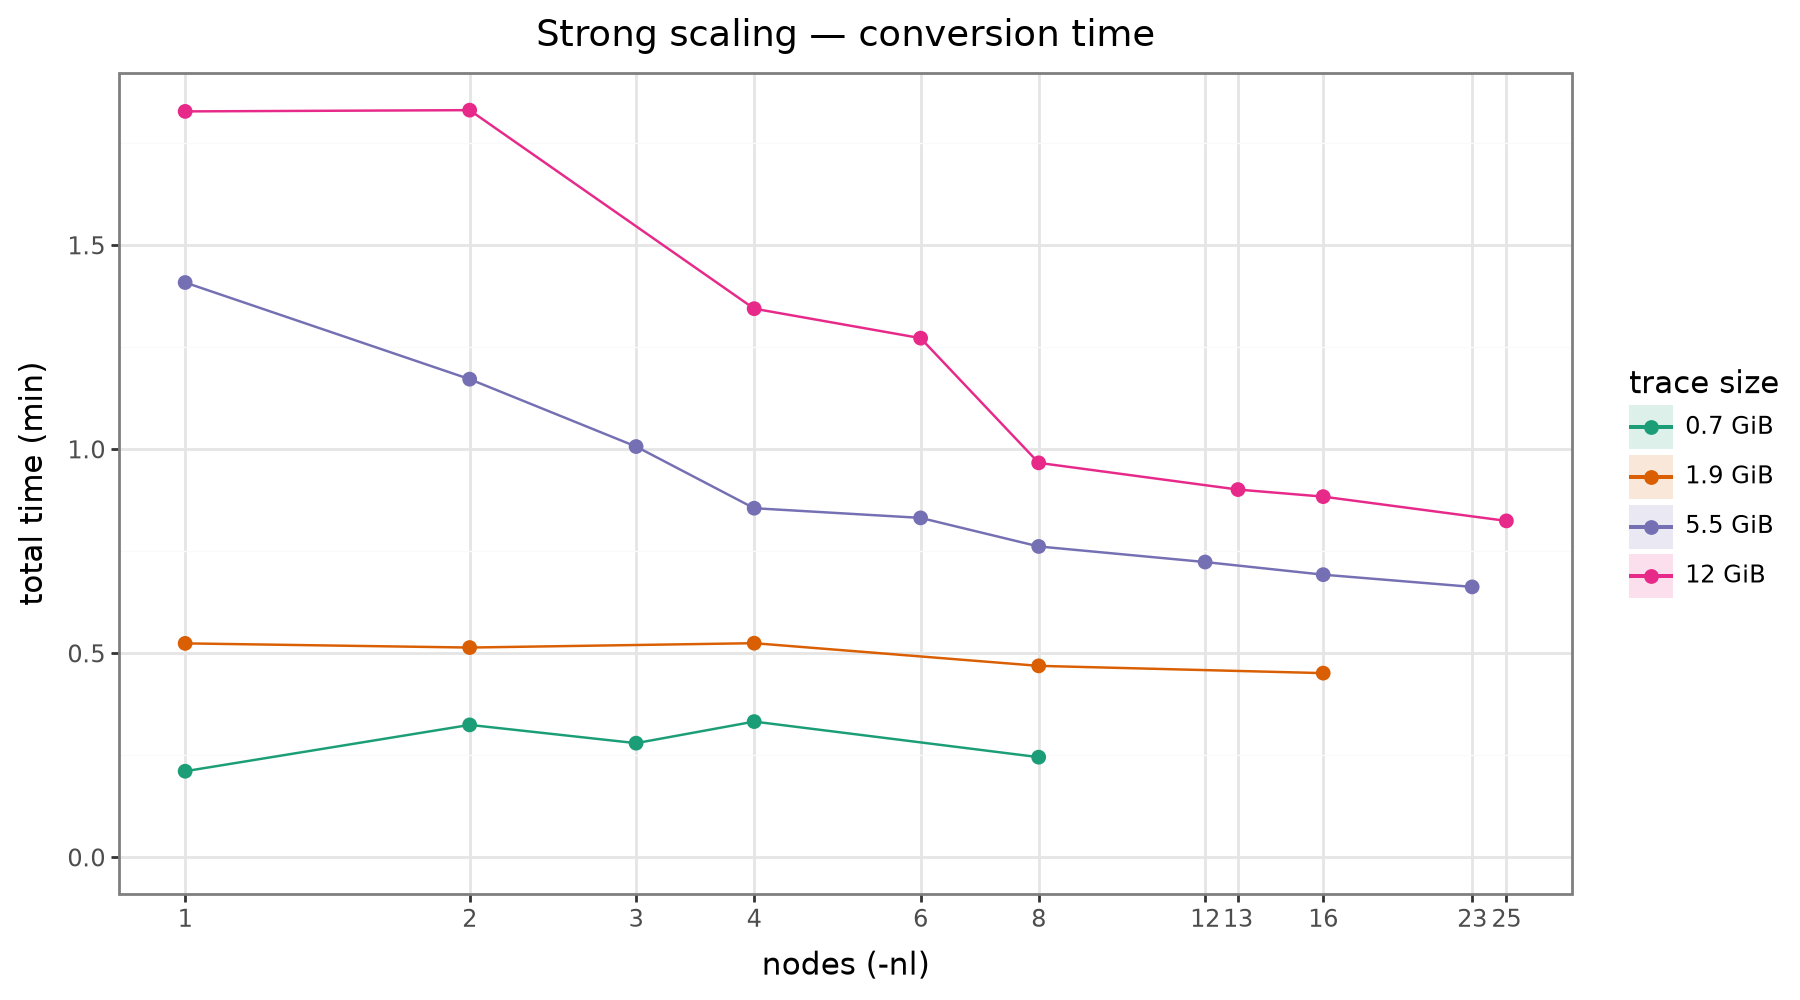

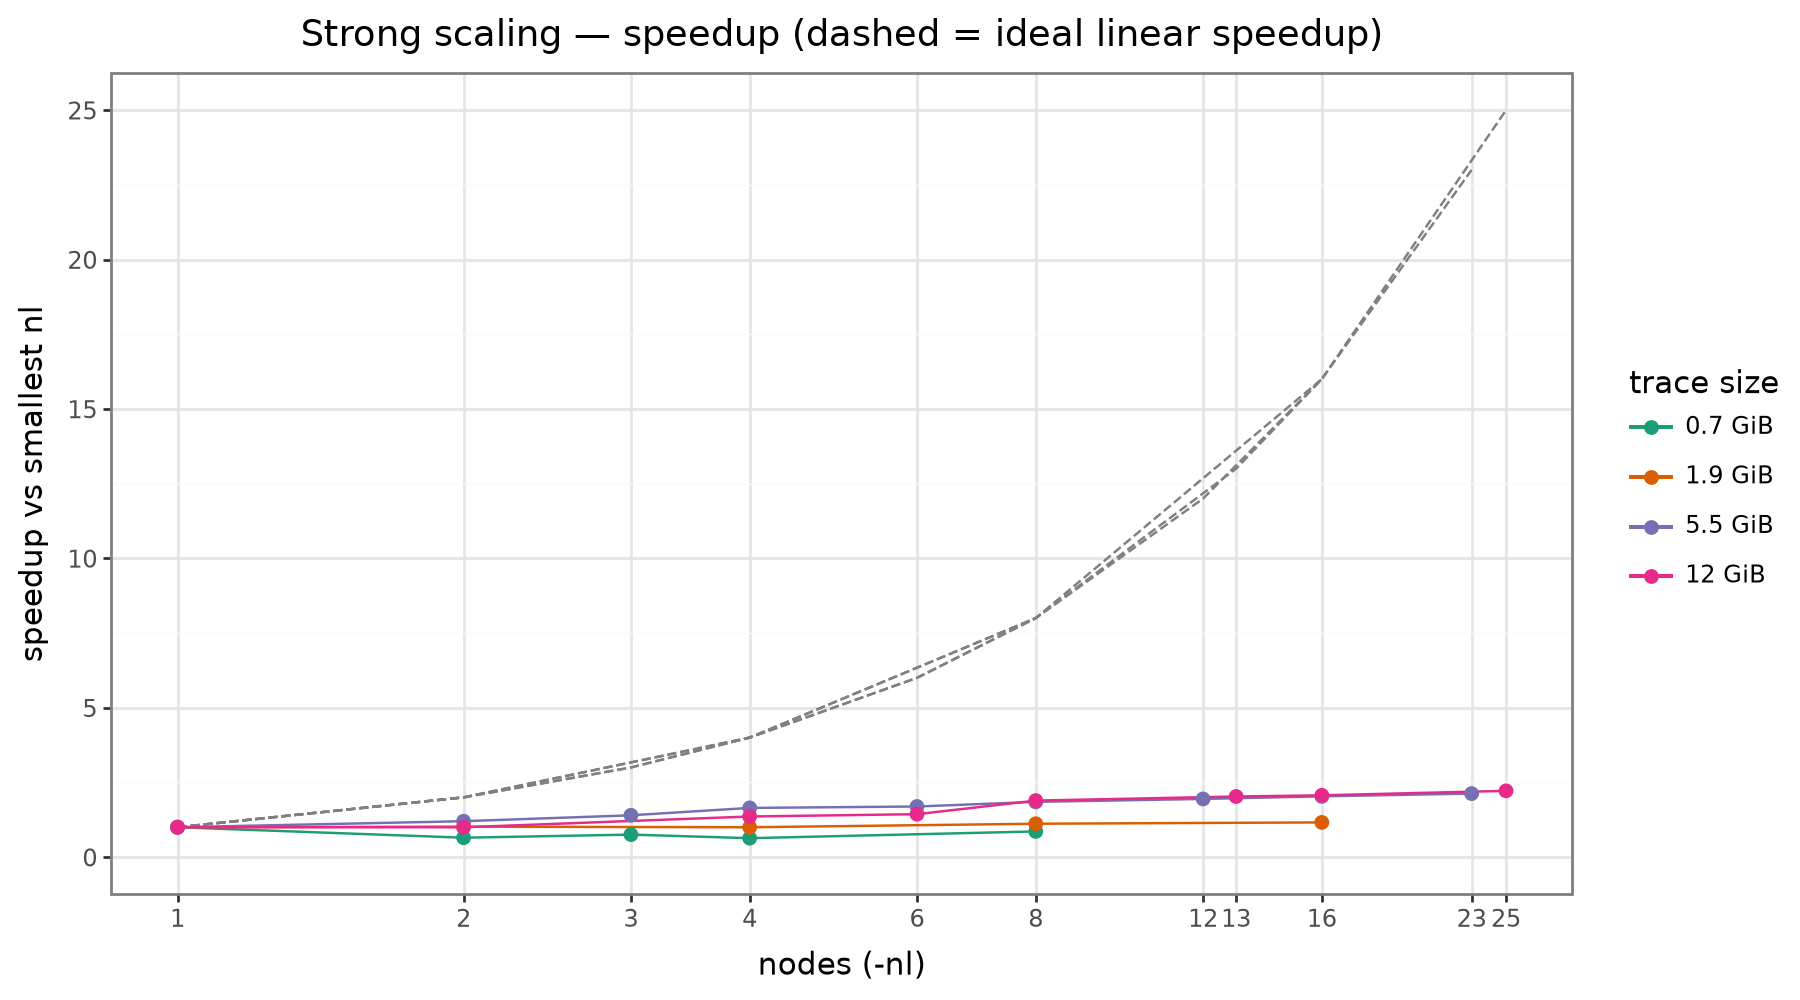

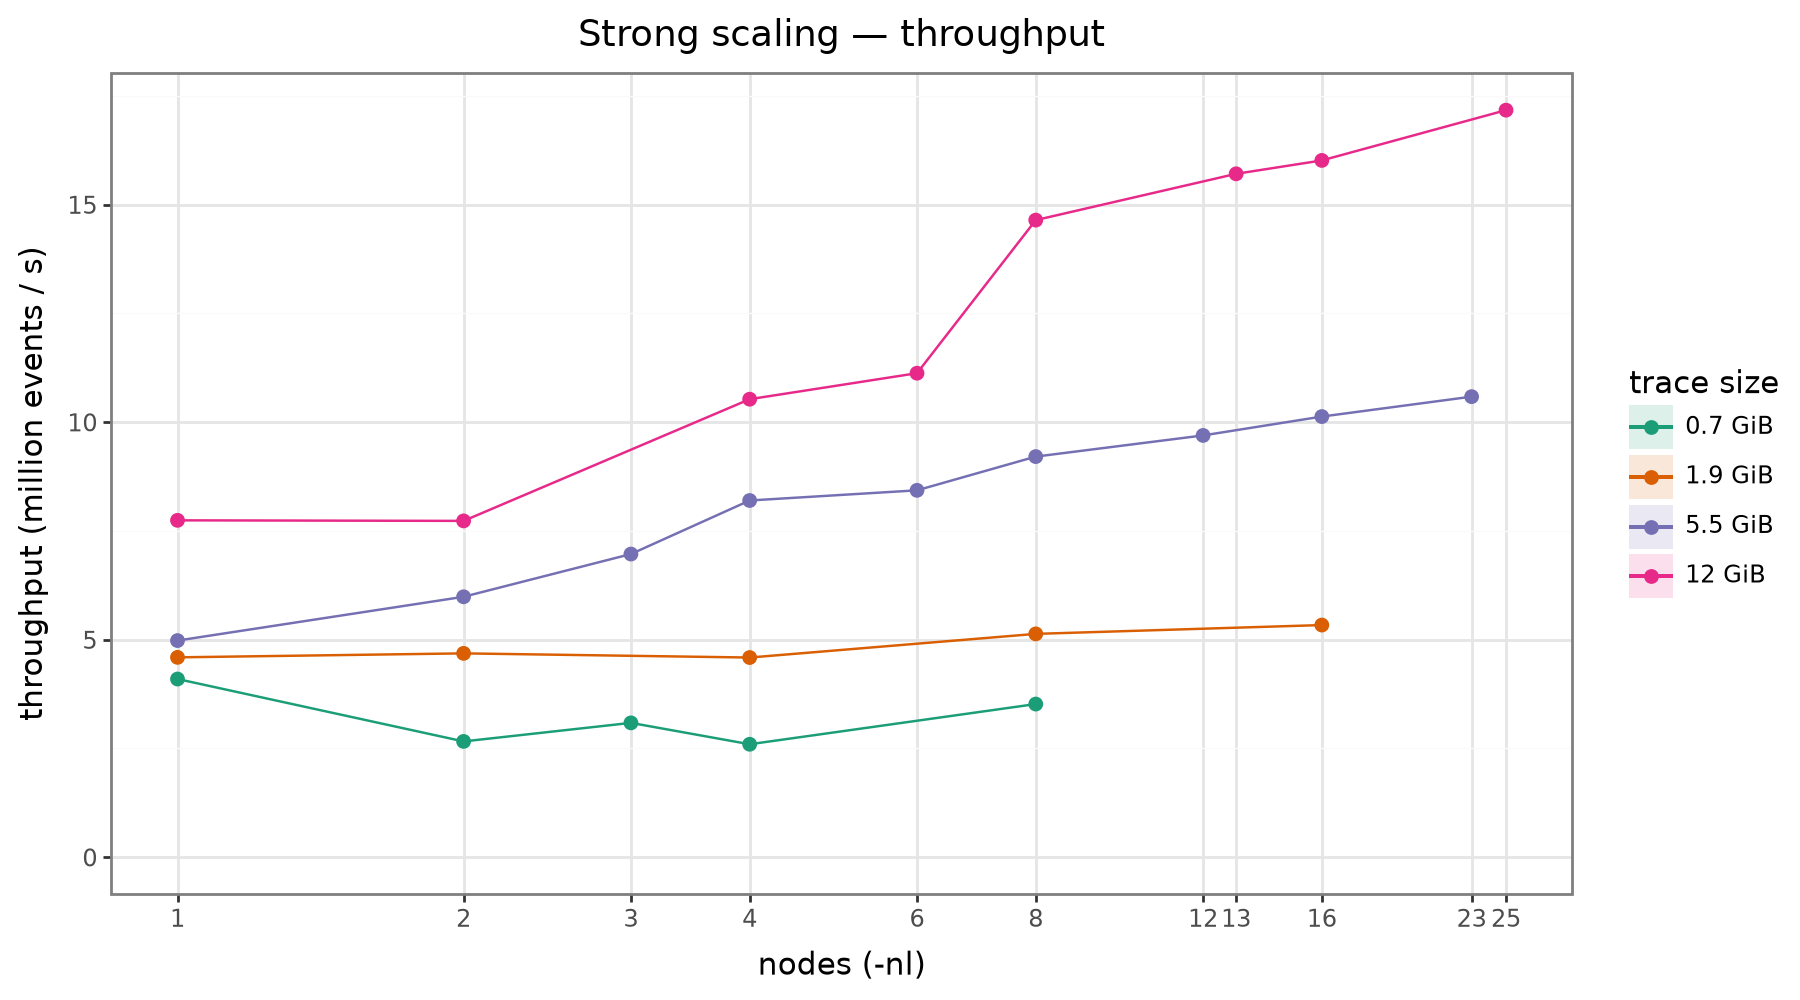

In [ ]:
def _agg(df, value):
    g = (df.groupby(["traced_nodes", "nl"])[value]
           .agg(med="median", lo="min", hi="max").reset_index())
    g["trace"] = trace_cat(g["traced_nodes"])
    return g


if not df_runs.empty:
    if STRONG_CONFIGS is not None:
        keep = [(t, n) in STRONG_CONFIGS
                for t, n in zip(df_runs["traced_nodes"], df_runs["nl"])]
        d = df_runs[keep].copy()
        if d.empty:
            print("No true strong-scaling configs among the loaded runs (only weak-scaling "
                  "bespoke node counts were found) — nothing to plot here; see Graph 3.")
    else:
        d = df_runs.copy()
        print("plan.json has no strong/weak config record (older run) — Graph 1 may include "
              "weak-scaling node counts too.")

    if not d.empty:
        d["time_min"] = d["totalTime"] / SEC_PER_MIN
        d["thr_Mevents"] = d["throughput"] / 1e6

        # G1a — total time (minutes), log-log: ideal scaling (time ~ 1/nodes) is a straight line
        s = _agg(d, "time_min")
        p1 = (ggplot(s, aes("nl", "med", color="trace", fill="trace"))
              + geom_ribbon(aes(ymin="lo", ymax="hi"), alpha=0.15, color=None)
              + geom_line() + geom_point(size=2)
              + node_axis(s["nl"]) + scale_y_continuous(trans="log2")
              + scale_color_brewer(type="qual", palette="Dark2")
              + scale_fill_brewer(type="qual", palette="Dark2")
              + labs(title="Strong scaling — conversion time (log-log)", x="nodes (-nl)",
                     y="total time (min, log2)", color="trace size", fill="trace size")
              + theme_bw() + theme(figure_size=(9, 5)))
        display(p1); _maybe_save(p1, "g1a_strong_time")

        # G1b — speedup vs each trace's smallest node count, log-log (dashed = ideal diagonal)
        parts = []
        for _, sub in s.groupby("trace", observed=True):
            sub = sub.sort_values("nl").copy()
            sub["speedup"] = sub["med"].iloc[0] / sub["med"]
            sub["ideal"] = sub["nl"] / sub["nl"].iloc[0]
            parts.append(sub)
        sp = pd.concat(parts)
        p2 = (ggplot(sp, aes("nl", "speedup", color="trace"))
              + geom_line(aes(y="ideal", group="trace"), color="grey", linetype="dashed")
              + geom_line() + geom_point(size=2)
              + node_axis(sp["nl"]) + scale_y_continuous(trans="log2")
              + scale_color_brewer(type="qual", palette="Dark2")
              + labs(title="Strong scaling — speedup (log-log; dashed = ideal linear speedup)",
                     x="nodes (-nl)", y="speedup vs smallest nl (log2)", color="trace size")
              + theme_bw() + theme(figure_size=(9, 5)))
        display(p2); _maybe_save(p2, "g1b_strong_speedup")

        # G1c — throughput (million events / s); linear, y-from-0
        st = _agg(d, "thr_Mevents")
        p3 = (ggplot(st, aes("nl", "med", color="trace", fill="trace"))
              + geom_ribbon(aes(ymin="lo", ymax="hi"), alpha=0.15, color=None)
              + geom_line() + geom_point(size=2)
              + node_axis(st["nl"]) + expand_limits(y=0)
              + scale_color_brewer(type="qual", palette="Dark2")
              + scale_fill_brewer(type="qual", palette="Dark2")
              + labs(title="Strong scaling — throughput", x="nodes (-nl)",
                     y="throughput (million events / s)", color="trace size", fill="trace size")
              + theme_bw() + theme(figure_size=(9, 5)))
        display(p3); _maybe_save(p3, "g1c_strong_throughput")
else:
    print("No runs to plot.")

## Graph 2 — Multi-trial consistency

Run-to-run spread for each config that has more than one trial (box + jittered points).
A tight box means the timing is reproducible.

In [33]:
if not df_runs.empty:
    d = df_runs.copy()
    d["n_trials"] = d.groupby(["traced_nodes", "nl"])["trial"].transform("nunique")
    d = d[d["n_trials"] > 1].copy()
    if not d.empty:
        d["time_min"] = d["totalTime"] / SEC_PER_MIN
        d["config"] = d["traced_nodes"].map(size_label) + " / nl" + d["nl"].astype(str)
        p = (ggplot(d, aes("config", "time_min"))
             + geom_boxplot(outlier_alpha=0.0)
             + geom_jitter(width=0.15, height=0, alpha=0.5, size=1.5)
             + expand_limits(y=0)
             + labs(title="Multi-trial consistency", x="config (trace size / nodes)",
                    y="total time (min)")
             + theme_bw()
             + theme(figure_size=(max(8, d["config"].nunique() * 0.6), 5),
                     axis_text_x=element_text(rotation=45, ha="right")))
        display(p); _maybe_save(p, "g2_multitrial")
    else:
        print("All configs have a single trial — nothing to compare.")
else:
    print("No runs to plot.")

All configs have a single trial — nothing to compare.


## Graph 3 — Weak scaling (constant data / node)

Each target holds data-per-node ≈ constant, so **ideal weak scaling is a flat total-time
line**. Per target we take, for each trace, the run whose data/node is closest to the target
(point labels = actual GiB/node). Time is in **minutes**; y starts at 0. The node axis is
**linear** here (not log) because weak-scaling node counts are bespoke per trace
(`round(size/target)`), not a power-of-two doubling sequence like strong scaling's grid —
log spacing would place them unevenly and look distorted.

- The **best-covered target** (the most traces, i.e. the most points) gets its own clean
  **time** plot and a matching **throughput** plot, so you can directly compare the same
  trace set both ways.
- The remaining targets are shown as small **facets** (one panel each) for total time.
- **Efficiency** = t(fewest nodes) / t(nodes) is the normalized, overlaid comparison across
  targets (1.0 = perfect; flat is good).

**Reading time vs. throughput together (they always agree — here's why).** Weak scaling
grows the trace size with the node count, so total events processed also grow ≈
proportionally with `N`. Throughput = events ÷ time, so if time were *perfectly flat*
(ideal scaling), throughput would rise **linearly through the origin** — not flat. The
dashed line on the throughput plot is exactly that ideal: `throughput(N_min) × (N/N_min)`.
A curve that **hugs the dashed line** is good scaling (matches a flat time curve); a curve
that **bows below** it is exactly as bad as a rising time curve — they're two views of the
same fact. Reading a "climbing" throughput line as automatically good (with no reference
line) is what made it look inconsistent with the time plot; the dashed line fixes that.

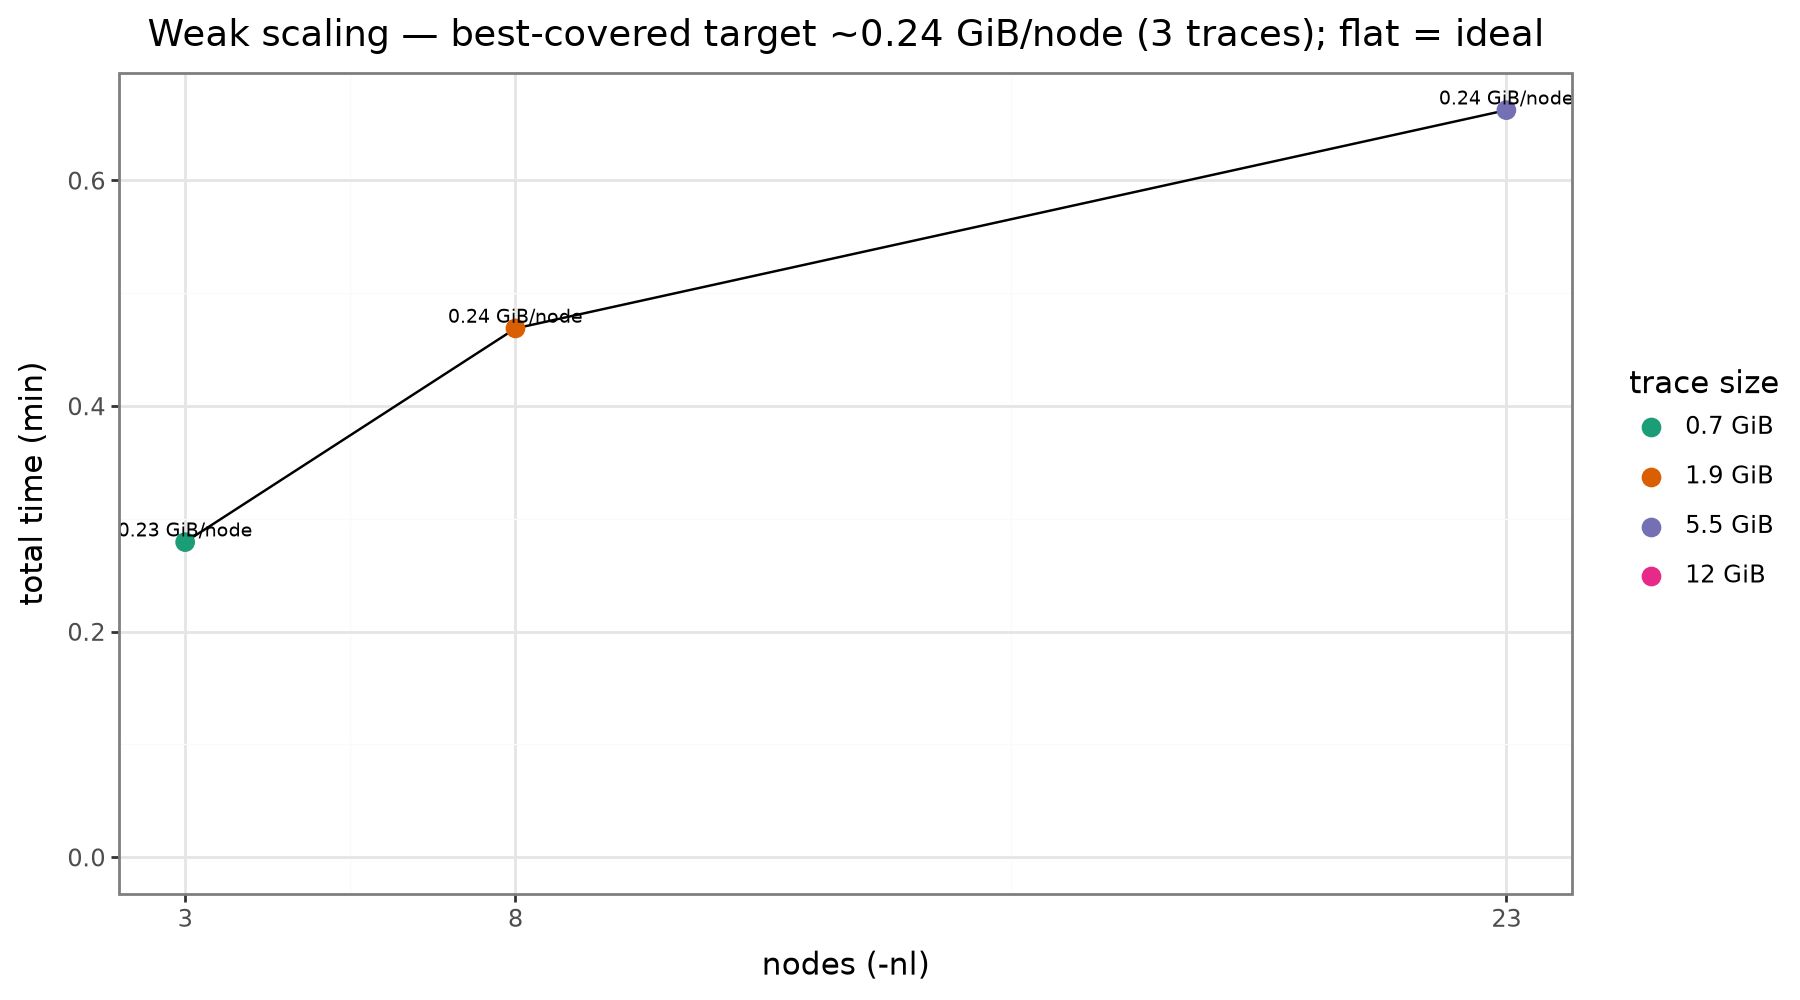

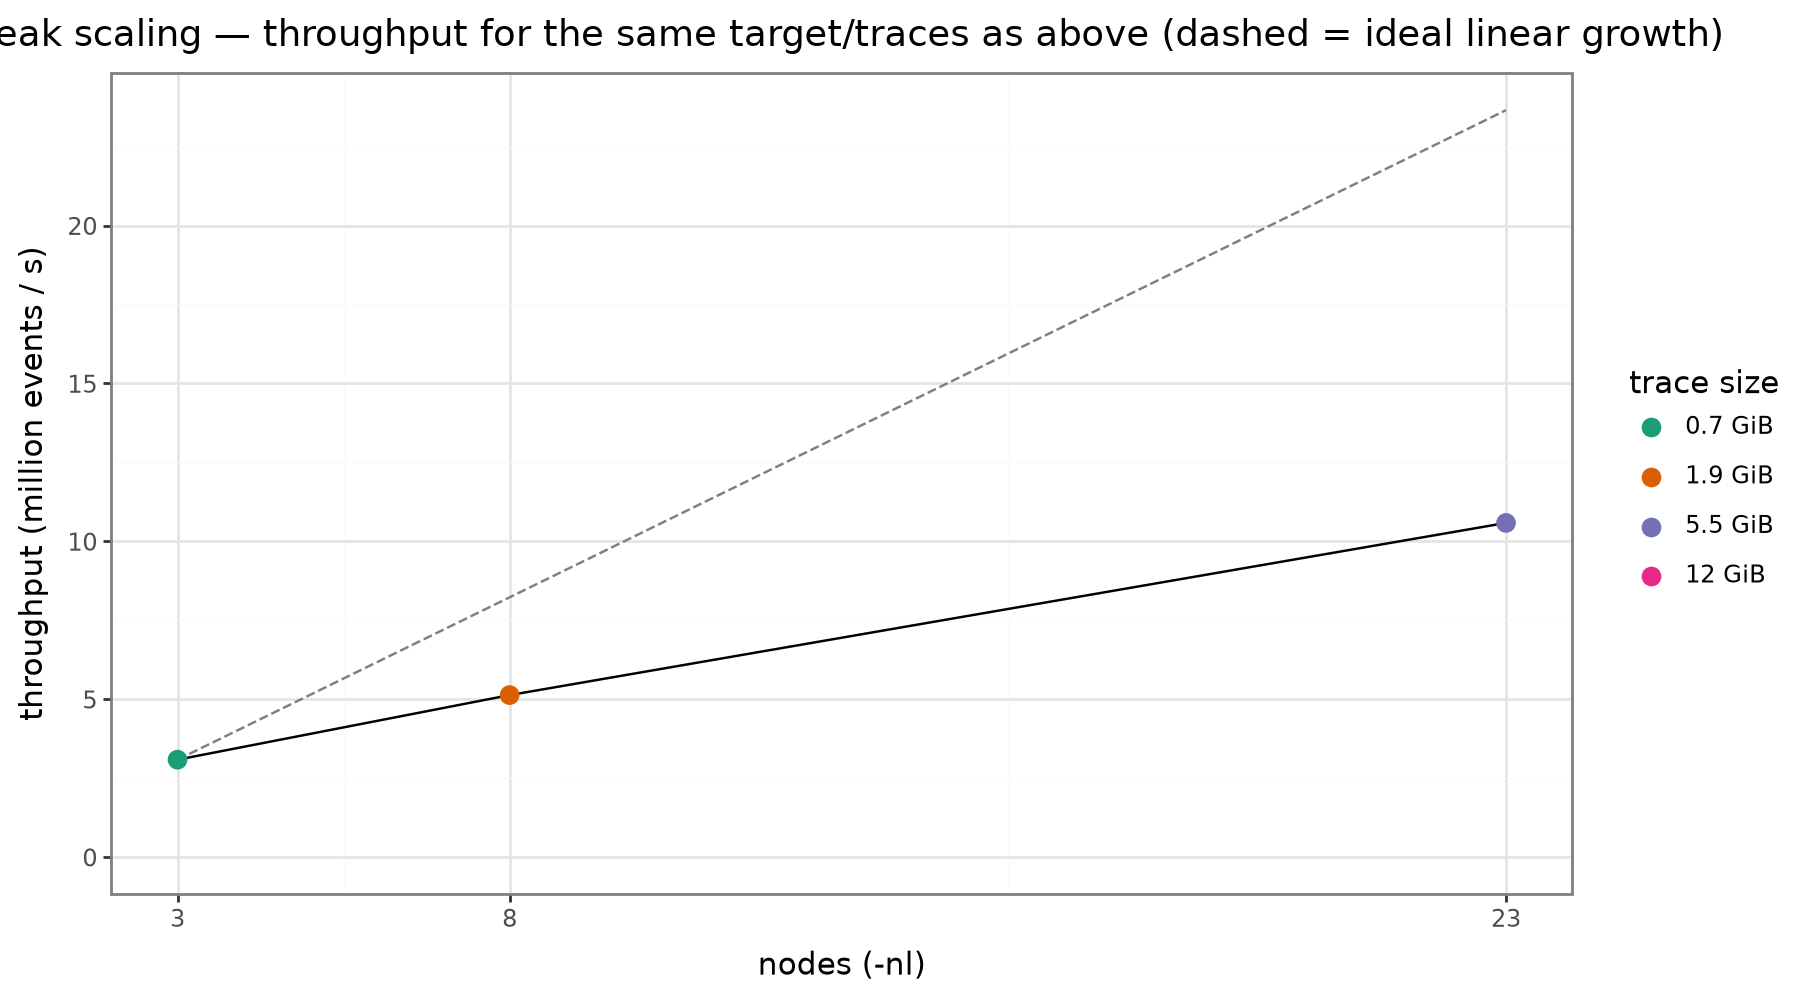

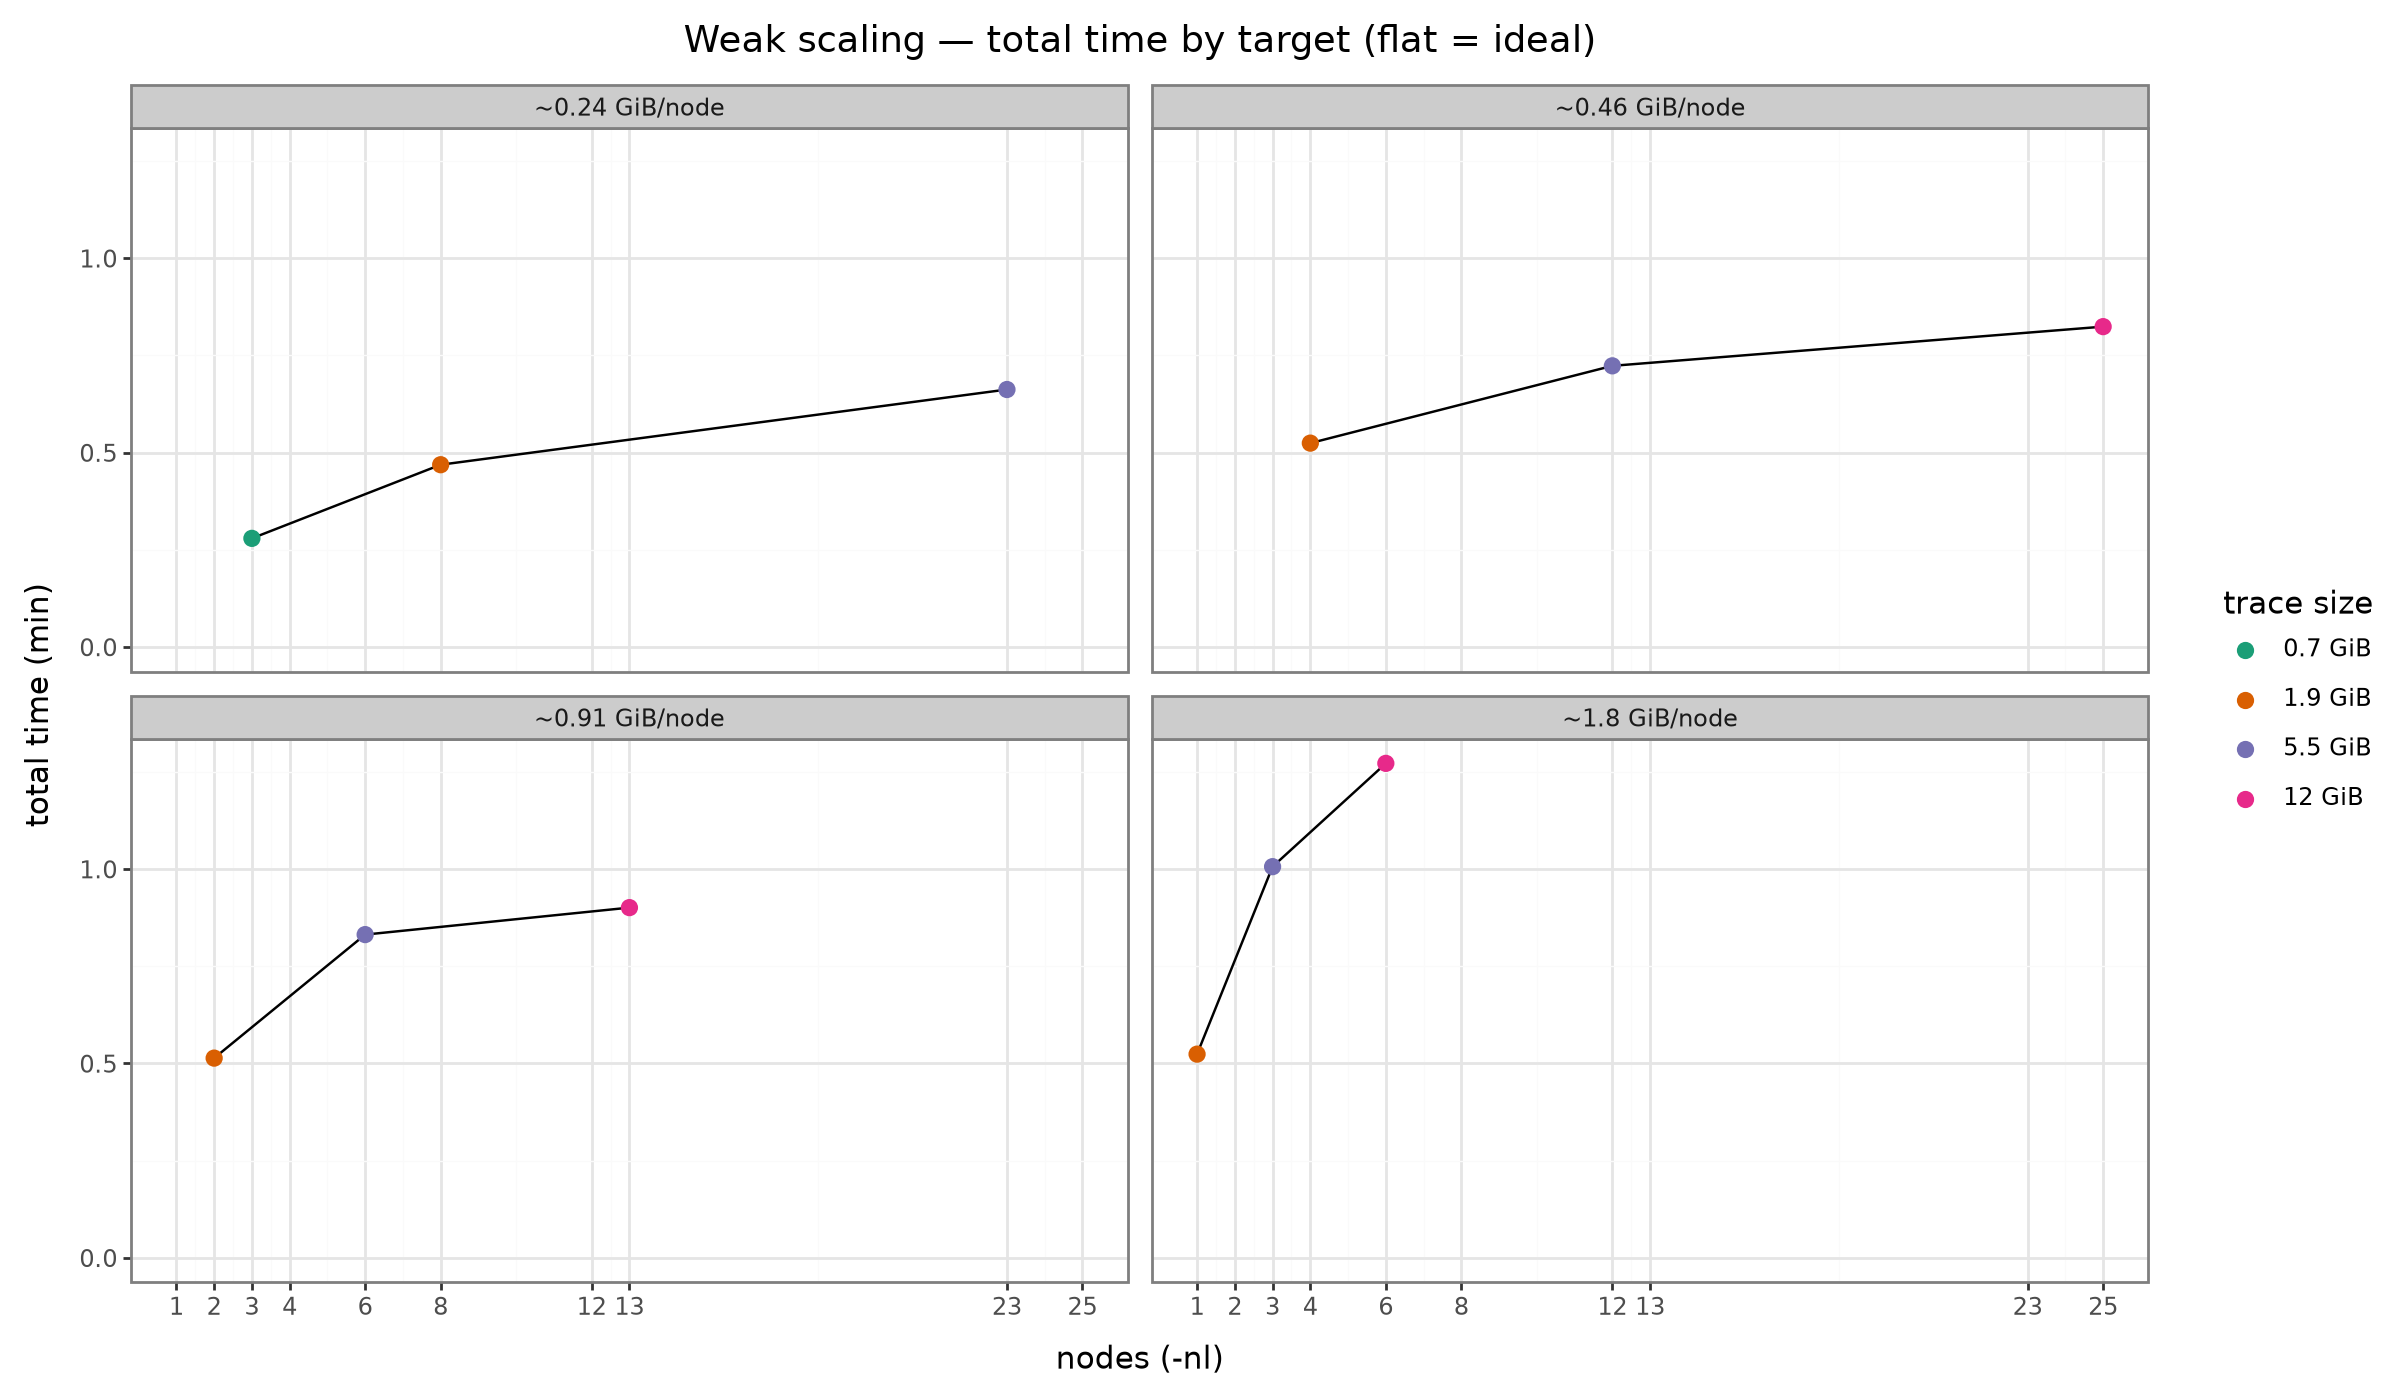

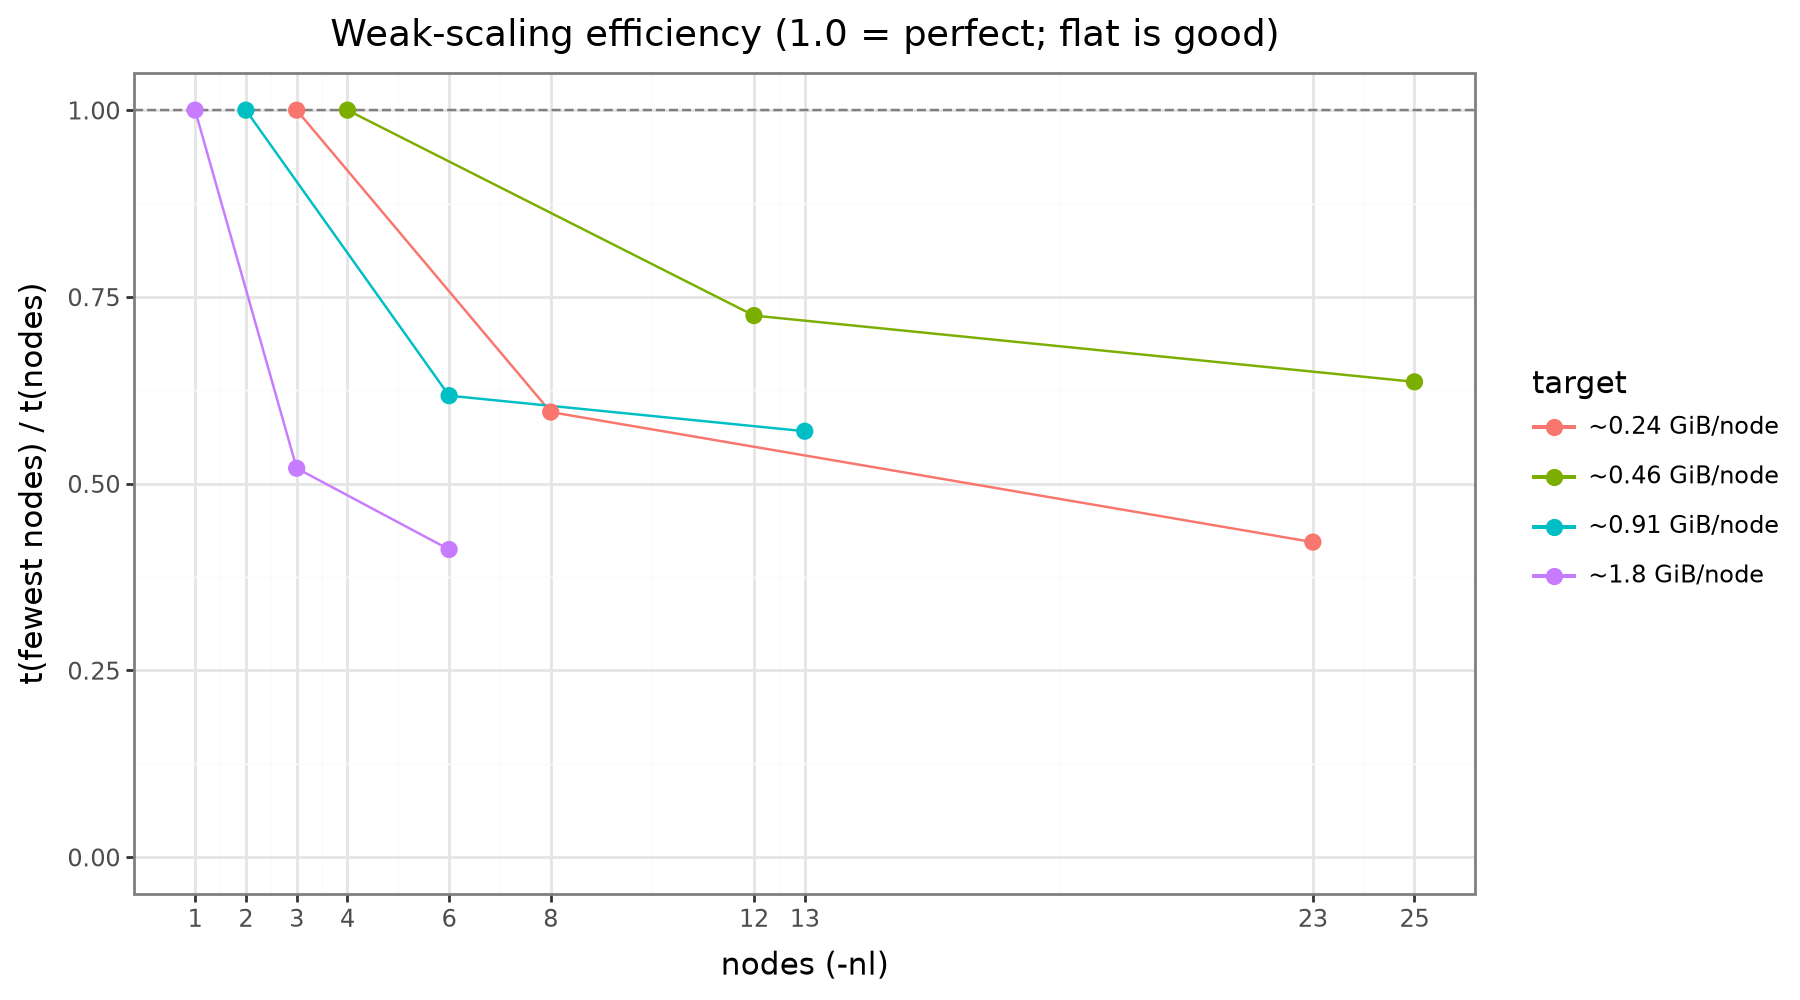

In [34]:
# Weak targets / tolerance / min-traces come from the analysis-config cell above
# (which reads the run's plan.json). Fall back to defaults if this cell is run alone.
WEAK_TARGETS_ANALYSIS = globals().get("WEAK_TARGETS_ANALYSIS", [0.5, 1.0, 3.0, 6.0, 12.0])
WEAK_TOL_ANALYSIS = globals().get("WEAK_TOL_ANALYSIS", 0.4)
MIN_TRACES_ANALYSIS = globals().get("MIN_TRACES_ANALYSIS", 3)


def weak_selection(df, targets, tol, min_traces):
    """Per target, pick each trace's run closest to the target GiB/node (within tol);
    keep targets covering >= min_traces traces."""
    agg = (df.groupby(["traced_nodes", "nl"])
             .agg(med=("totalTime", "median"), lo=("totalTime", "min"),
                  hi=("totalTime", "max"), thr=("throughput", "median"),
                  gpn=("gib_per_node", "first")).reset_index())
    frames = []
    for g in targets:
        picks = []
        for _, sub in agg.groupby("traced_nodes"):
            sub = sub.assign(dev=(sub["gpn"] - g).abs() / g).sort_values("dev")
            if sub.iloc[0]["dev"] <= tol:
                picks.append(sub.iloc[0])
        if len(picks) >= min_traces:
            f = pd.DataFrame(picks)
            f["target"] = g
            frames.append(f)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


weak_sel = (weak_selection(df_runs, WEAK_TARGETS_ANALYSIS, WEAK_TOL_ANALYSIS, MIN_TRACES_ANALYSIS)
            if not df_runs.empty else pd.DataFrame())

if not weak_sel.empty:
    weak_sel = weak_sel.copy()
    weak_sel["time_min"] = weak_sel["med"] / SEC_PER_MIN
    weak_sel["lo_min"] = weak_sel["lo"] / SEC_PER_MIN
    weak_sel["hi_min"] = weak_sel["hi"] / SEC_PER_MIN
    weak_sel["thr_million"] = weak_sel["thr"] / 1e6
    weak_sel["trace"] = trace_cat(weak_sel["traced_nodes"])
    weak_sel["target_lab"] = "~" + weak_sel["target"].astype(str) + " GiB/node"
    weak_sel["gpn_lab"] = weak_sel["gpn"].round(2).astype(str) + " GiB/node"

    # Best-covered target = the one with the most traces (ties -> smaller GiB/node).
    counts = weak_sel.groupby("target").size()
    best_target = sorted(counts.index, key=lambda g: (-counts[g], g))[0]
    best = weak_sel[weak_sel["target"] == best_target].sort_values("nl").copy()

    # G3a — the best-covered target on its own (clean; flat = ideal)
    p1 = (ggplot(best, aes("nl", "time_min"))
          + geom_ribbon(aes(ymin="lo_min", ymax="hi_min"), alpha=0.2)
          + geom_line() + geom_point(aes(color="trace"), size=3)
          + geom_text(aes(label="gpn_lab"), size=7, va="bottom", format_string="{}")
          + node_axis_linear(best["nl"]) + expand_limits(y=0)
          + scale_color_brewer(type="qual", palette="Dark2")
          + labs(title=f"Weak scaling — best-covered target ~{best_target} GiB/node "
                       f"({len(best)} traces); flat = ideal",
                 x="nodes (-nl)", y="total time (min)", color="trace size")
          + theme_bw() + theme(figure_size=(9, 5)))
    display(p1); _maybe_save(p1, "g3a_weak_best_target_time")

    # G3b — same target/traces, throughput, with the matching "ideal" reference line.
    # If time were flat, events/time would rise LINEARLY (not flatten) because weak scaling
    # grows the data with the node count -- that line is the dashed reference below.
    n_min, thr_min = best["nl"].iloc[0], best["thr_million"].iloc[0]
    best["ideal_thr"] = thr_min * best["nl"] / n_min
    p2 = (ggplot(best, aes("nl", "thr_million"))
          + geom_line(aes(y="ideal_thr"), color="grey", linetype="dashed")
          + geom_line() + geom_point(aes(color="trace"), size=3)
          + node_axis_linear(best["nl"]) + expand_limits(y=0)
          + scale_color_brewer(type="qual", palette="Dark2")
          + labs(title="Weak scaling — throughput for the same target/traces as above "
                       "(dashed = ideal linear growth)",
                 x="nodes (-nl)", y="throughput (million events / s)", color="trace size")
          + theme_bw() + theme(figure_size=(9, 5)))
    display(p2); _maybe_save(p2, "g3b_weak_best_target_throughput")

    # G3c — every target, faceted (avoids overlaying many lines on one axis)
    if weak_sel["target"].nunique() > 1:
        p3 = (ggplot(weak_sel, aes("nl", "time_min"))
              + geom_line() + geom_point(aes(color="trace"), size=2.5)
              + facet_wrap("target_lab")
              + node_axis_linear(weak_sel["nl"]) + expand_limits(y=0)
              + scale_color_brewer(type="qual", palette="Dark2")
              + labs(title="Weak scaling — total time by target (flat = ideal)",
                     x="nodes (-nl)", y="total time (min)", color="trace size")
              + theme_bw() + theme(figure_size=(12, 7)))
        display(p3); _maybe_save(p3, "g3c_weak_time_facets")

    # G3d — efficiency: the fair, normalized weak-scaling metric (overlaid comparison)
    eff = []
    for _, sub in weak_sel.groupby("target"):
        sub = sub.sort_values("nl").copy()
        sub["efficiency"] = sub["med"].iloc[0] / sub["med"]
        eff.append(sub)
    eff = pd.concat(eff)
    p4 = (ggplot(eff, aes("nl", "efficiency", color="target_lab"))
          + geom_hline(yintercept=1.0, linetype="dashed", color="grey")
          + geom_line() + geom_point(size=2.5)
          + node_axis_linear(eff["nl"]) + expand_limits(y=0)
          + labs(title="Weak-scaling efficiency (1.0 = perfect; flat is good)",
                 x="nodes (-nl)", y="t(fewest nodes) / t(nodes)", color="target")
          + theme_bw() + theme(figure_size=(9, 5)))
    display(p4); _maybe_save(p4, "g3d_weak_efficiency")
else:
    print(f"No weak-scaling curves met the coverage bar (need >= {MIN_TRACES_ANALYSIS} "
          "traces per target).")

## Graph 4 — Per-config task profile

For every `(trace, nodes)` config: the per-locale distribution of task time (violin +
jitter), and a stacked breakdown of where each locale spends time (leaf phases only, so
nothing is double-counted). One pair of plots per config — this can be many plots.

In [35]:
# Leaf timing columns (exclude aggregates that double-count).
LEAF_COLS = ["Open (s)", "Setup (s)", "EnterCB (s)", "LeaveCB (s)", "MetricCB (s)",
             "libOTF2 (s)", "WriteCG (s)", "WriteMet (s)"]


def task_profile(traced_nodes, nl):
    d = df_tasks[(df_tasks["traced_nodes"] == traced_nodes) & (df_tasks["nl"] == nl)].copy()
    if d.empty:
        return
    lbl = size_label(traced_nodes)
    width = min(14, 3 + nl * 0.4)
    d["total_min"] = d["Total (s)"] / SEC_PER_MIN
    p1 = (ggplot(d, aes("factor(Locale)", "total_min"))
          + geom_violin(fill="steelblue", alpha=0.4)
          + geom_jitter(width=0.15, alpha=0.4, size=1)
          + expand_limits(y=0)
          + labs(title=f"Task time by locale — {lbl} trace, nl={nl}",
                 x="locale", y="task total (min)")
          + theme_bw() + theme(figure_size=(width, 4)))
    # display(p1)

    leaves = [c for c in LEAF_COLS if c in d.columns]
    m = (d.groupby("Locale")[leaves].mean().reset_index()
           .melt("Locale", var_name="phase", value_name="seconds"))
    m["minutes"] = m["seconds"] / SEC_PER_MIN
    m["phase"] = m["phase"].str.replace(" (s)", "", regex=False)
    p2 = (ggplot(m, aes("factor(Locale)", "minutes", fill="phase"))
          + geom_col()
          + expand_limits(y=0)
          + labs(title=f"Timing breakdown by locale (mean) — {lbl} trace, nl={nl}",
                 x="locale", y="time (min)", fill="phase")
          + theme_bw() + theme(figure_size=(width, 4)))
    # display(p2)


if not df_tasks.empty:
    cfgs = (df_tasks[["traced_nodes", "nl"]].drop_duplicates()
            .sort_values(["traced_nodes", "nl"]))
    print(f"{len(cfgs)} config(s) with task-level data.")
    for _, c in cfgs.iterrows():
        task_profile(int(c["traced_nodes"]), int(c["nl"]))
else:
    print("No task-level data.")

27 config(s) with task-level data.


## Graph 5 — Phase breakdown (and saving figures)

Mean wall time per phase for each config (leaf phases; the `Total` row is excluded). To
export every figure as PNG, set `SAVE_PLOTS = True` in the analysis-config cell and re-run
the graph cells — each one calls `_maybe_save(...)` into the run's `plots/` folder.

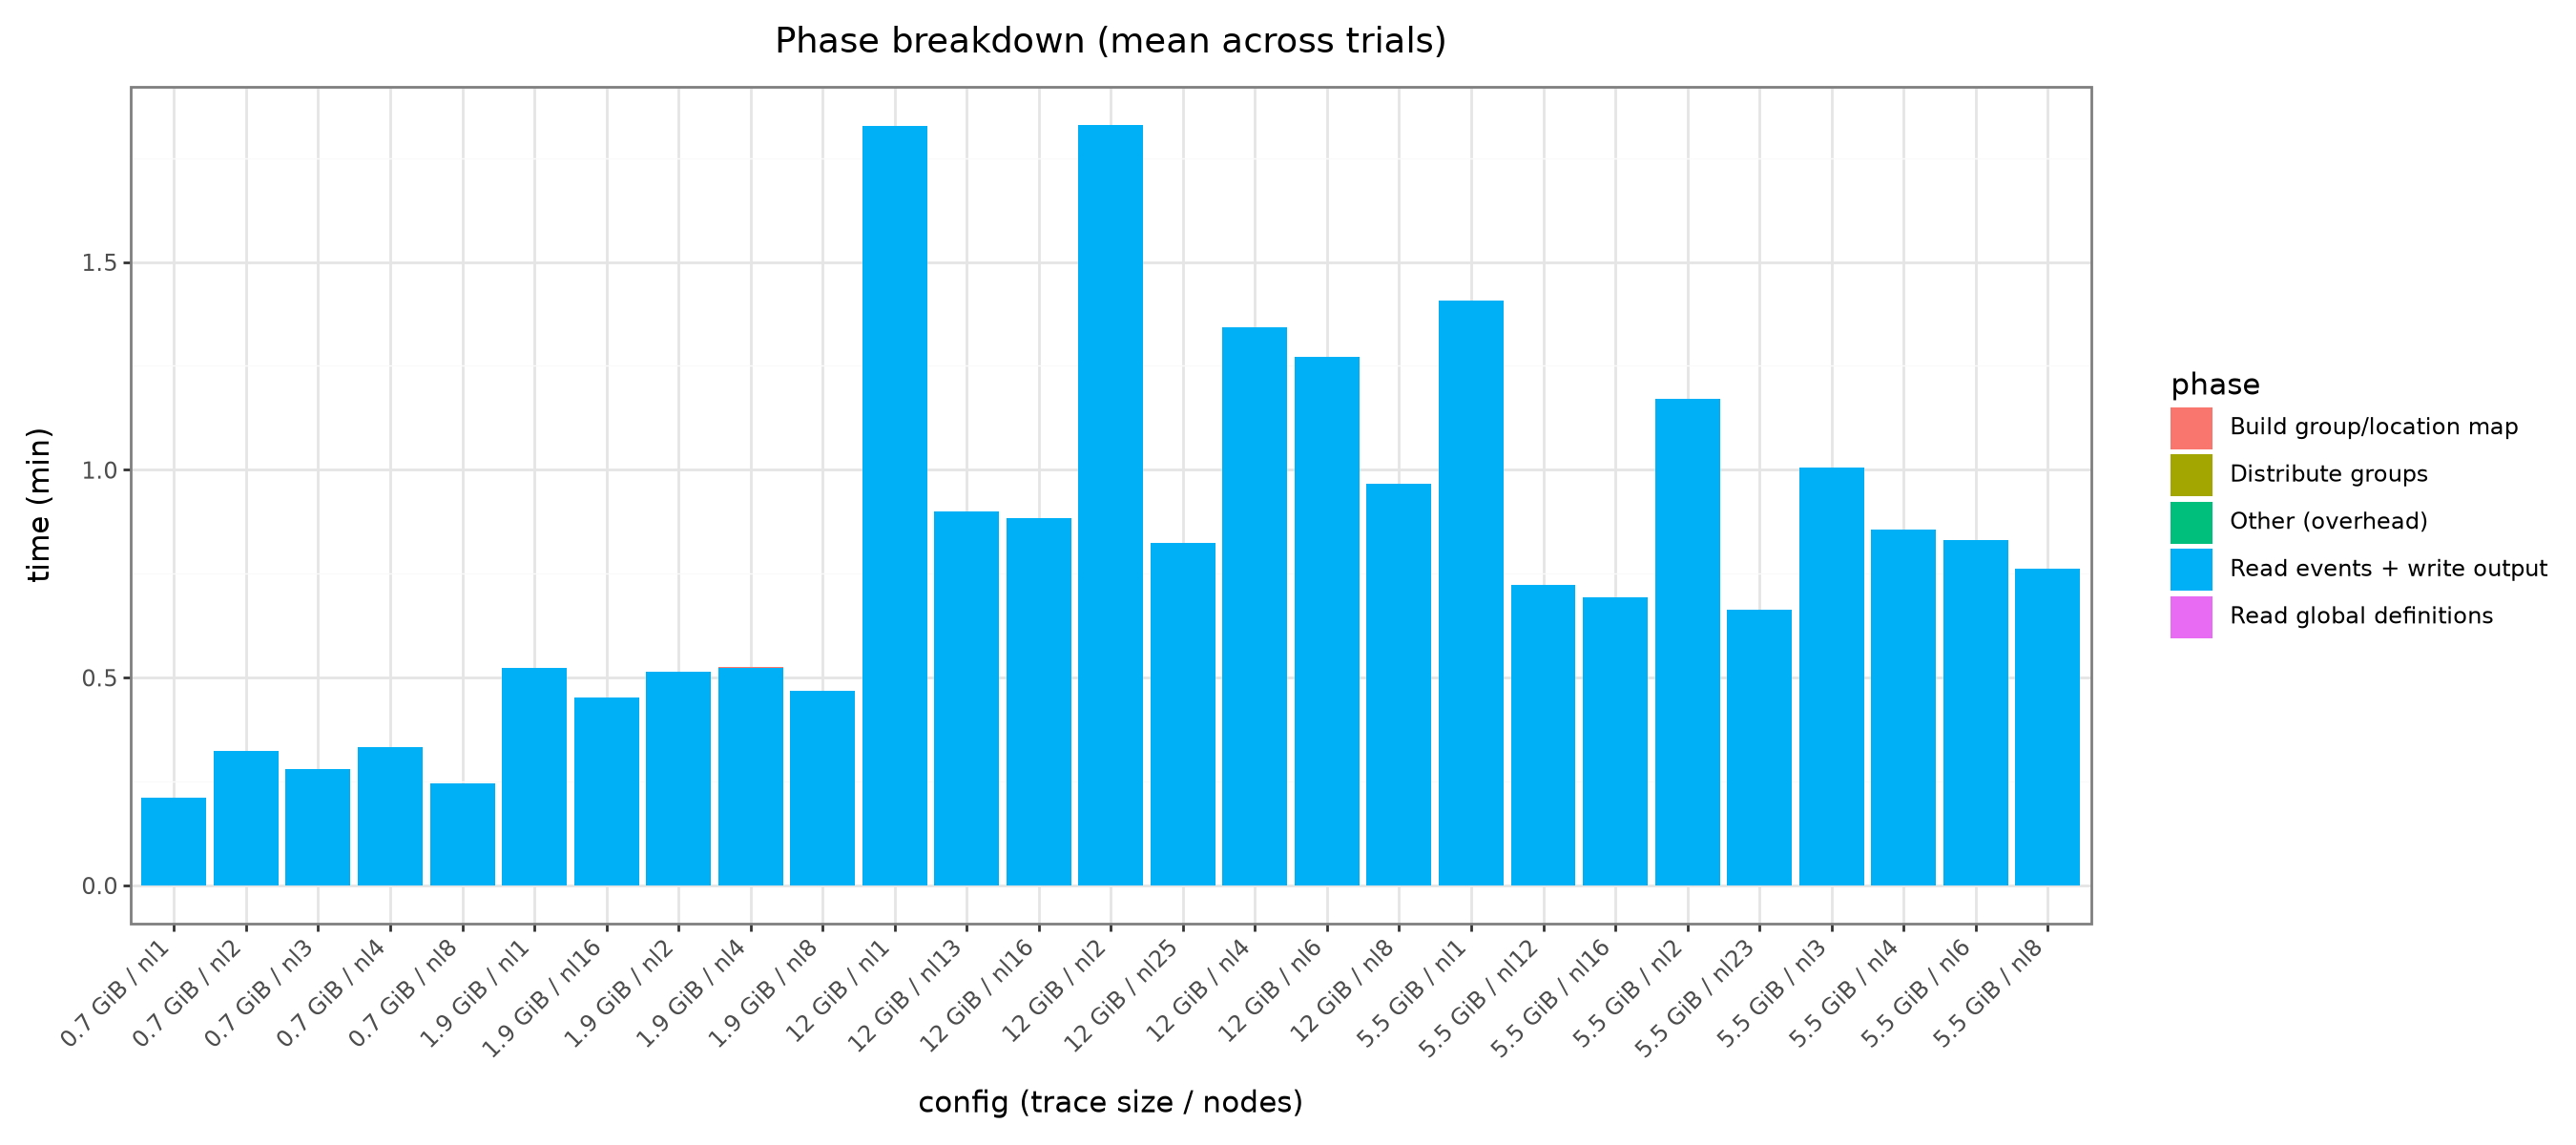

In [36]:
if not df_phases.empty:
    d = df_phases[df_phases["phase"] != "Total"].copy()
    g = d.groupby(["traced_nodes", "nl", "phase"])["time"].mean().reset_index()
    g["minutes"] = g["time"] / SEC_PER_MIN
    g["config"] = g["traced_nodes"].map(size_label) + " / nl" + g["nl"].astype(str)
    p = (ggplot(g, aes("config", "minutes", fill="phase"))
         + geom_col()
         + expand_limits(y=0)
         + labs(title="Phase breakdown (mean across trials)",
                x="config (trace size / nodes)", y="time (min)", fill="phase")
         + theme_bw()
         + theme(figure_size=(max(9, g["config"].nunique() * 0.5), 6),
                 axis_text_x=element_text(rotation=45, ha="right")))
    display(p); _maybe_save(p, "g5_phase_breakdown")
else:
    print("No phase-level data.")